In [1]:

import os
# Set working directory to project root
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

# Phase 2 EDA — Compliance Risk Investigator AI
# Nova Pharma Inc | Anomaly Detection Engine
# Generated: 2026-04-04

from datetime import date
from pathlib import Path

import duckdb
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

# Style
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)

# Color palette — maps to risk tier severity
CRITICAL = '#d62728'
HIGH     = '#ff7f0e'
MEDIUM   = '#ffbb78'
LOW      = '#2ca02c'
TIER_COLORS = {'critical': CRITICAL, 'high': HIGH, 'medium': MEDIUM, 'low': LOW}

# Figures output directory
FIGURES_DIR = Path('notebooks/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
FIG_NUM = [0]  # mutable counter for sequential naming

def save_fig(name):
    FIG_NUM[0] += 1
    path = FIGURES_DIR / f'fig_{FIG_NUM[0]:02d}_{name}.png'
    plt.savefig(path, dpi=150, bbox_inches='tight')
    print(f'  Saved: {path}')

print('Setup complete. Figures will be saved to:', FIGURES_DIR)

Setup complete. Figures will be saved to: notebooks/figures


In [2]:
# ── Load all Phase 2 outputs ──────────────────────────────────────────────────
feature_store      = pd.read_parquet('features/outputs/feature_store.parquet')
feature_store_raw  = pd.read_parquet('features/outputs/feature_store_raw.parquet')
ground_truth       = pd.read_parquet('features/outputs/ground_truth_labels.parquet')
rule_flags         = pd.read_parquet('models/outputs/rule_flags.parquet')
if_scores          = pd.read_parquet('models/outputs/if_scores.parquet')
risk_scores        = pd.read_parquet('models/outputs/risk_scores.parquet')
feature_importance = pd.read_csv('models/outputs/feature_importance.csv')

# DuckDB tables (graceful fallback if unavailable)
risk_profile = event_features = benchmark = None
try:
    con = duckdb.connect('data/processed/compliance.duckdb', read_only=True)
    risk_profile   = con.execute('SELECT * FROM mart_hcp_risk_profile').df()
    benchmark      = con.execute('SELECT * FROM mart_benchmark').df()
    event_features = con.execute('SELECT * FROM mart_event_features').df()
    con.close()
    print('DuckDB tables loaded')
except Exception as e:
    print(f'DuckDB unavailable: {e}')

# Master merged frame — risk scores + GT labels + state + heuristic score
master = (
    risk_scores
    .merge(ground_truth[['hcp_id', 'has_violation']], on='hcp_id')
    .merge(feature_store_raw[['hcp_id', 'state', 'combined_raw_risk_score']], on='hcp_id')
)

print('\n── Data Loaded ──────────────────────────────────────────────')
for name, df in [
    ('feature_store', feature_store),
    ('feature_store_raw', feature_store_raw),
    ('ground_truth', ground_truth),
    ('rule_flags', rule_flags),
    ('if_scores', if_scores),
    ('risk_scores', risk_scores),
]:
    print(f'  {name:<28} {df.shape}')

viol_n    = int(ground_truth['has_violation'].sum())
viol_rate = ground_truth['has_violation'].mean()
print(f'\n  Violation rate: {viol_rate:.1%} ({viol_n:,} of {len(ground_truth):,} HCPs)')
print(f'  Risk tiers:     {risk_scores["risk_tier"].value_counts().to_dict()}')

DuckDB tables loaded

── Data Loaded ──────────────────────────────────────────────
  feature_store                (97011, 99)
  feature_store_raw            (97011, 117)
  ground_truth                 (97011, 4)
  rule_flags                   (97011, 148)
  if_scores                    (97011, 5)
  risk_scores                  (97011, 13)

  Violation rate: 24.5% (23,727 of 97,011 HCPs)
  Risk tiers:     {'low': 67562, 'medium': 21103, 'high': 8055, 'critical': 291}


---
## 1. Risk Score Distributions

Three scoring signals are combined into the unified risk score: the **Isolation Forest anomaly score** (statistical deviation from peer HCP behaviour), the **rule-based score** (severity-weighted count of fired compliance flags), and the **unified risk score** (60% rule + 40% IF).

**Business insight:** The IF score is right-skewed (most HCPs score 0–10), while the rule score has a bimodal distribution (zero flags vs. many flags). The unified score moderates both extremes.

**Compliance implication:** The 479 HCPs in the critical tier (risk_score ≥ 75) represent immediate investigation candidates. The 35,800 in the high tier warrant priority review.

  Saved: notebooks/figures/fig_01_score_distributions.png


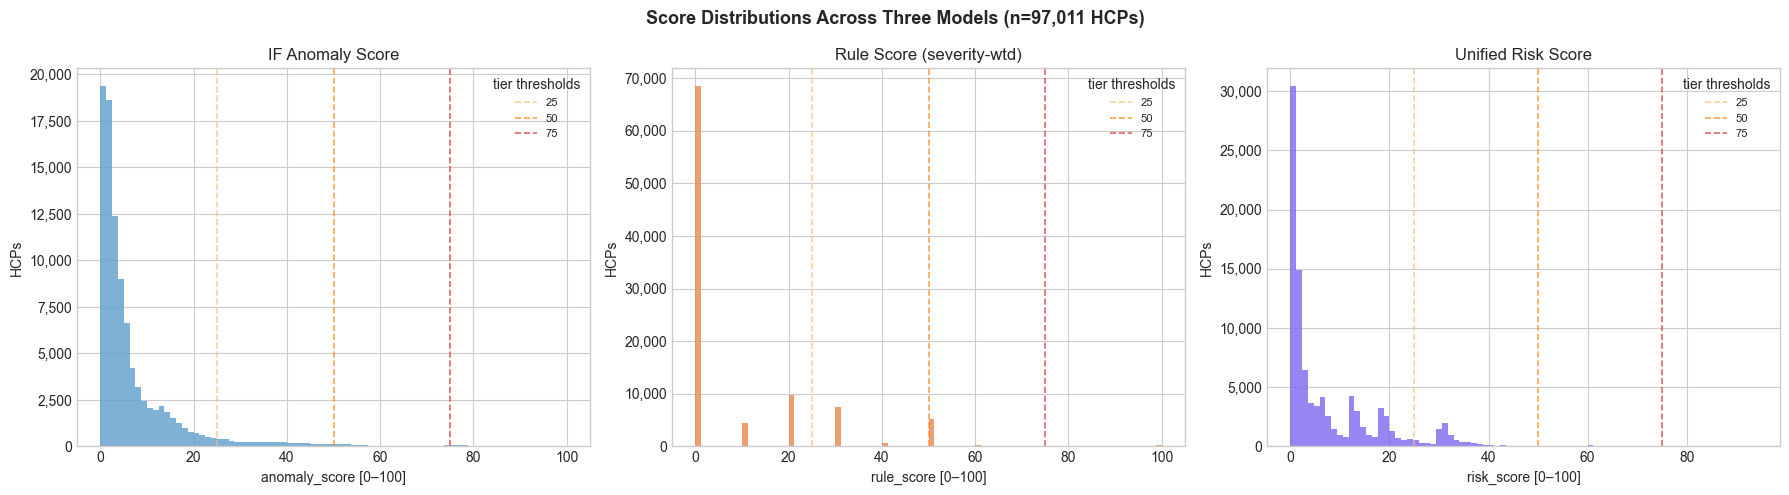

/var/folders/1p/pdcjl8l17sbf2wgrjhl8pj340000gn/T/ipykernel_39206/2929424126.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxes = axes[1].boxplot(box_data, labels=tier_order, patch_artist=True, notch=False, showfliers=False)


  Saved: notebooks/figures/fig_02_tier_distribution.png


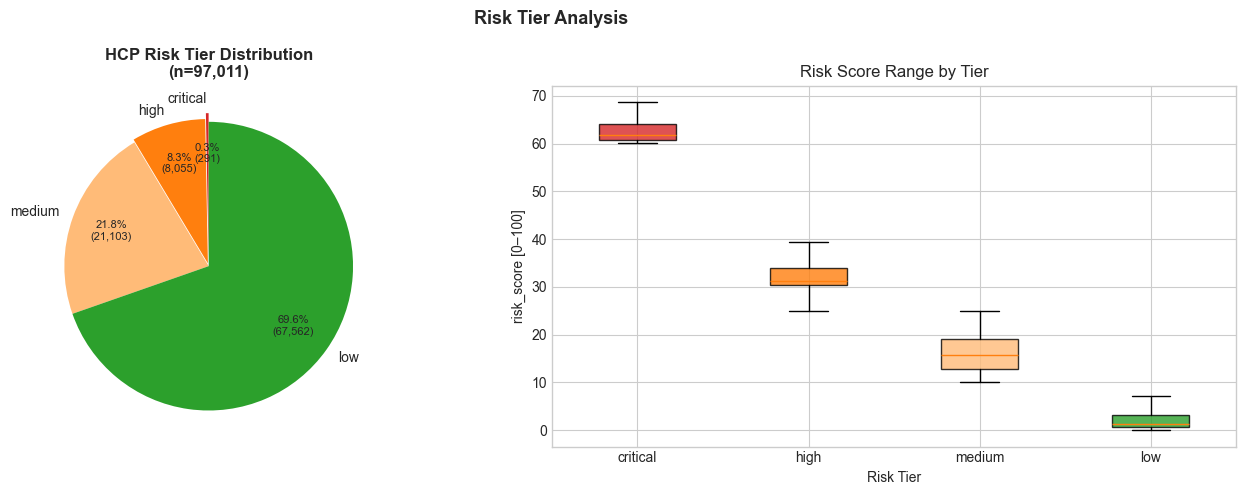

In [3]:
# ── Section 1: Risk Score Distributions ──────────────────────────────────────
thresh_kw = dict(linestyle='--', alpha=0.7, linewidth=1.2)
tier_order = ['critical', 'high', 'medium', 'low']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

score_specs = [
    (if_scores['anomaly_score'],   '#5f9ecc', 'IF Anomaly Score',           'anomaly_score [0–100]'),
    (risk_scores['rule_score'],    '#e8884f', 'Rule Score (severity-wtd)',  'rule_score [0–100]'),
    (risk_scores['risk_score'],    '#7b68ee', 'Unified Risk Score',         'risk_score [0–100]'),
]
for ax, (scores, color, title, xlabel) in zip(axes, score_specs):
    ax.hist(scores, bins=80, color=color, edgecolor='none', alpha=0.8)
    for t, c, lbl in [(25, MEDIUM, '25'), (50, HIGH, '50'), (75, CRITICAL, '75')]:
        ax.axvline(t, color=c, label=lbl, **thresh_kw)
    ax.set(title=title, xlabel=xlabel, ylabel='HCPs')
    ax.legend(title='tier thresholds', fontsize=8)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

fig.suptitle('Score Distributions Across Three Models (n=97,011 HCPs)', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('score_distributions')
plt.show()

# Pie + box plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tier_counts = risk_scores['risk_tier'].value_counts()
counts  = [int(tier_counts.get(t, 0)) for t in tier_order]
explode = [0.06, 0.02, 0, 0]
wedges, texts, autotexts = axes[0].pie(
    counts,
    labels=[f'{t}' for t in tier_order],
    colors=[TIER_COLORS[t] for t in tier_order],
    autopct=lambda p: f'{p:.1f}%\n({int(round(p/100*97011)):,})',
    explode=explode, startangle=90, pctdistance=0.72,
)
for at in autotexts:
    at.set_fontsize(8)
axes[0].set_title('HCP Risk Tier Distribution\n(n=97,011)', fontweight='bold')

box_data   = [risk_scores[risk_scores['risk_tier'] == t]['risk_score'].values for t in tier_order]
boxes = axes[1].boxplot(box_data, labels=tier_order, patch_artist=True, notch=False, showfliers=False)
for patch, t in zip(boxes['boxes'], tier_order):
    patch.set_facecolor(TIER_COLORS[t])
    patch.set_alpha(0.8)
axes[1].set(title='Risk Score Range by Tier', xlabel='Risk Tier', ylabel='risk_score [0–100]')

fig.suptitle('Risk Tier Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('tier_distribution')
plt.show()

---
## 2. Rule-Based Flag Analysis

23 compliance rules from `rules.json` are applied to each HCP. Flags are severity-weighted (critical=+40 pts, high=+20, medium=+10) to form the rule score.

**Business insight:** `flag_fmv_non_compliance` fires for 23,141 HCPs (23.9%) — FMV documentation gaps are the most pervasive issue. Cap breach flags fire for ~18–19K HCPs each year, driven by high-spend KOLs.

**Compliance implication:** Co-occurring flags (cap breach + FMV non-compliance) are the highest-risk combination — HCPs who both exceed thresholds and lack documentation.

  Saved: notebooks/figures/fig_03_rule_flag_analysis.png


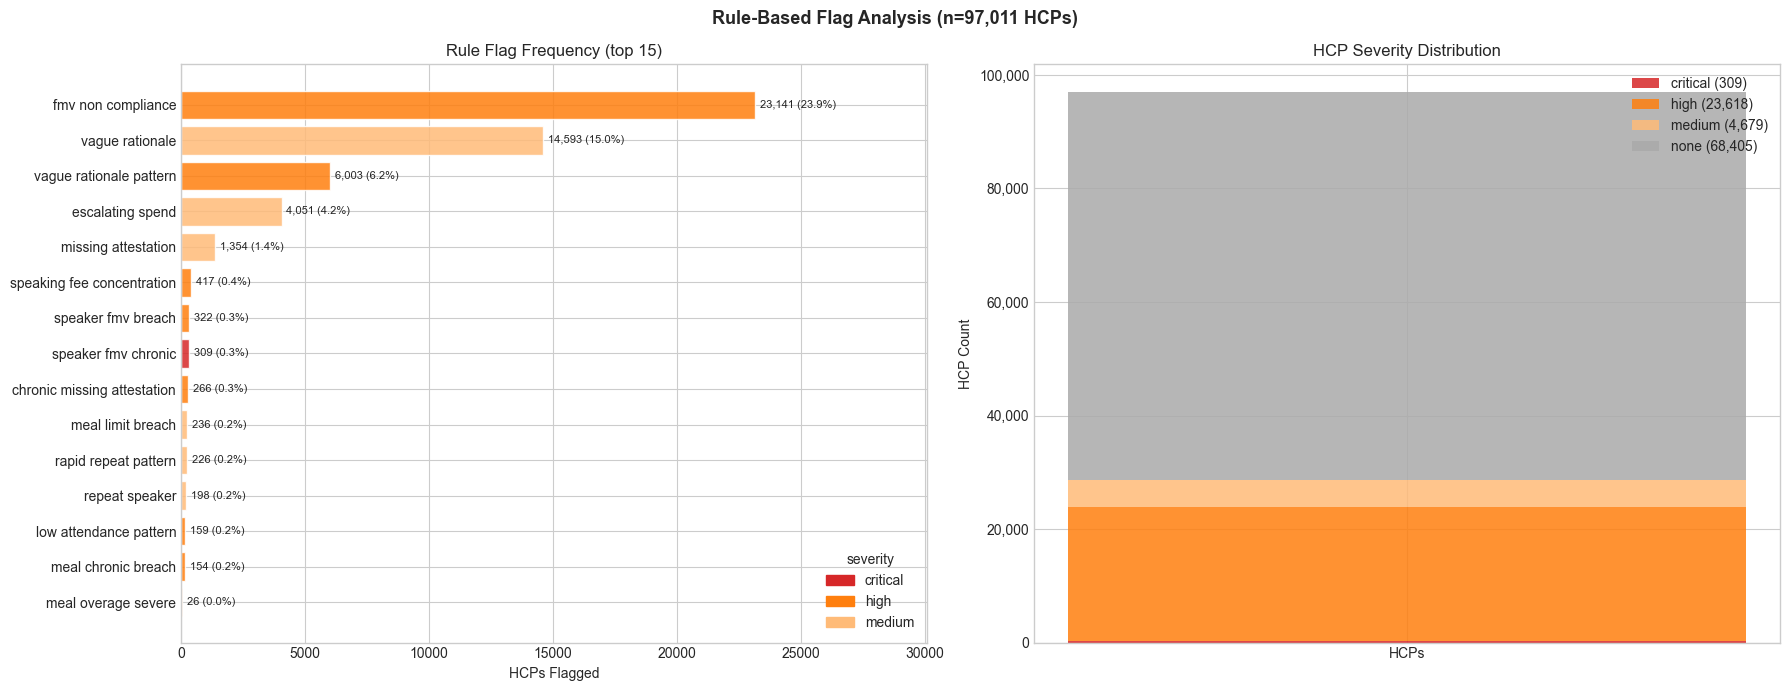

  Saved: notebooks/figures/fig_04_flag_cooccurrence_heatmap.png


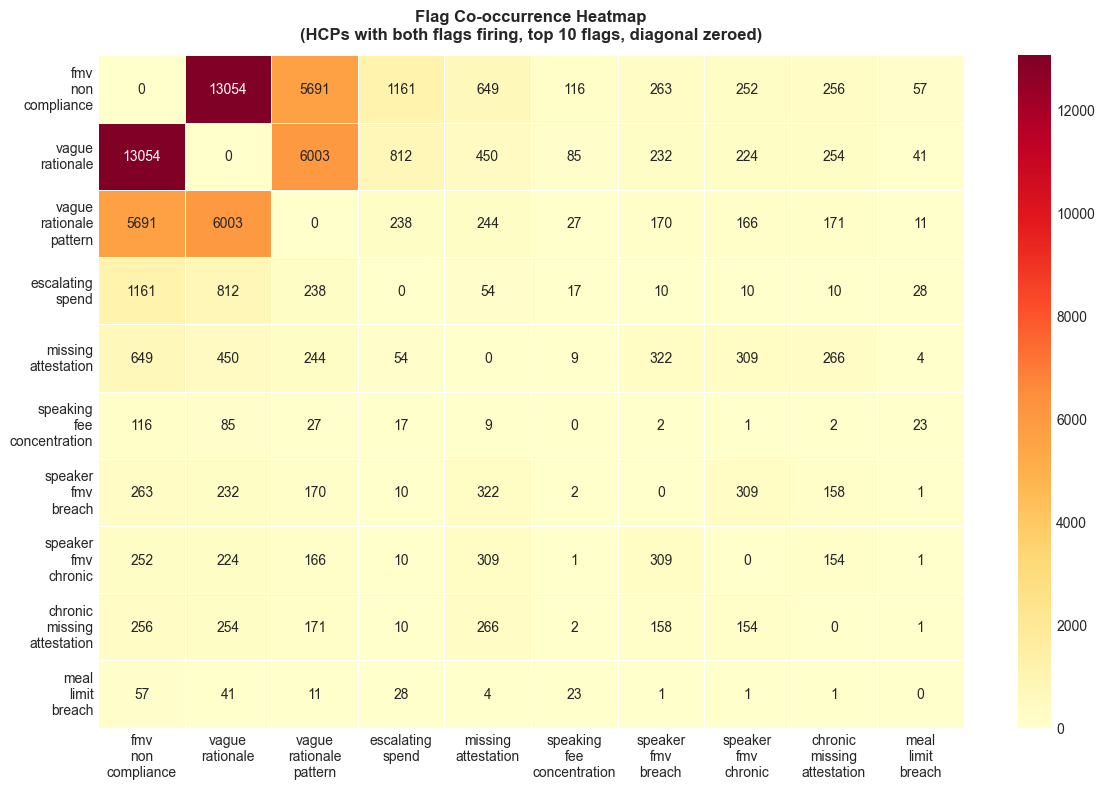

In [4]:
# ── Section 2: Rule Flag Analysis ────────────────────────────────────────────
severity_map = {
    'flag_meal_limit_breach': 'medium',     'flag_meal_chronic_breach': 'high',
    'flag_meal_overage_severe': 'high',     'flag_annual_cap_breach_2022': 'critical',
    'flag_annual_cap_breach_2023': 'critical','flag_annual_cap_breach_2024': 'critical',
    'flag_near_cap_2024': 'high',           'flag_chronic_near_cap': 'high',
    'flag_speaker_fmv_breach': 'high',      'flag_speaker_fmv_chronic': 'critical',
    'flag_repeat_speaker': 'medium',        'flag_high_repeat_speaker': 'high',
    'flag_low_attendance_pattern': 'high',  'flag_rapid_repeat_pattern': 'medium',
    'flag_missing_attestation': 'medium',   'flag_chronic_missing_attestation': 'high',
    'flag_vague_rationale': 'medium',       'flag_vague_rationale_pattern': 'high',
    'flag_fmv_non_compliance': 'high',      'flag_rep_concentration': 'medium',
    'flag_speaking_fee_concentration': 'high','flag_escalating_spend': 'medium',
    'flag_escalating_rank': 'medium',
}

flag_cols   = [c for c in rule_flags.columns if c.startswith('flag_') and rule_flags[c].dtype == bool]
flag_counts = {c: int(rule_flags[c].sum()) for c in flag_cols}
sorted_flags = sorted(flag_counts.items(), key=lambda x: -x[1])
top15        = sorted_flags[:15]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Horizontal bar — top 15 flags by count
ax = axes[0]
labels     = [f.replace('flag_', '').replace('_', ' ') for f, _ in top15]
vals       = [v for _, v in top15]
bar_colors = [TIER_COLORS.get(severity_map.get(f, 'medium'), HIGH) for f, _ in top15]
bars = ax.barh(labels[::-1], vals[::-1], color=bar_colors[::-1], alpha=0.85, edgecolor='white')
for bar, val in zip(bars, vals[::-1]):
    pct = val / 97011 * 100
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,} ({pct:.1f}%)', va='center', fontsize=8)
ax.set(title='Rule Flag Frequency (top 15)', xlabel='HCPs Flagged', ylabel='')
ax.set_xlim(0, max(vals) * 1.3)
legend_handles = [
    mpatches.Patch(color=CRITICAL, label='critical'),
    mpatches.Patch(color=HIGH,     label='high'),
    mpatches.Patch(color=MEDIUM,   label='medium'),
]
ax.legend(handles=legend_handles, title='severity', loc='lower right')

# Stacked severity distribution
ax = axes[1]
sev_order  = ['critical', 'high', 'medium', 'none']
sev_counts = rule_flags['most_severe_flag'].value_counts()
sev_vals   = [int(sev_counts.get(s, 0)) for s in sev_order]
bottom     = 0
for s, v in zip(sev_order, sev_vals):
    ax.bar(['HCPs'], [v], bottom=bottom, color=TIER_COLORS.get(s, '#aaa'),
           label=f'{s} ({v:,})', alpha=0.85)
    bottom += v
ax.set(title='HCP Severity Distribution', ylabel='HCP Count')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(loc='upper right')

fig.suptitle('Rule-Based Flag Analysis (n=97,011 HCPs)', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('rule_flag_analysis')
plt.show()

# Co-occurrence heatmap — top 10 flags
top10_cols  = [f for f, _ in sorted_flags[:10]]
flag_matrix = rule_flags[top10_cols].astype(int)
co_matrix   = flag_matrix.T.dot(flag_matrix)
np.fill_diagonal(co_matrix.values, 0)
short_labels = [c.replace('flag_', '').replace('_', '\n') for c in top10_cols]

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(
    co_matrix, annot=True, fmt='d', cmap='YlOrRd',
    xticklabels=short_labels, yticklabels=short_labels,
    linewidths=0.5, ax=ax,
)
ax.set_title('Flag Co-occurrence Heatmap\n(HCPs with both flags firing, top 10 flags, diagonal zeroed)',
             fontweight='bold', pad=12)
plt.tight_layout()
save_fig('flag_cooccurrence_heatmap')
plt.show()

---
## 3. Feature Importance

Feature importance is computed as the absolute Pearson correlation (|r|) between each feature and the IF anomaly score. This is a proxy — Phase 3 will replace it with SHAP values.

**Business insight:** `combined_raw_risk_score` (r=0.695) dominates — the heuristic risk score from the dbt marts is strongly correlated with the IF statistical outlier score, validating that both approaches identify the same high-risk HCPs.

**Compliance implication:** Interaction frequency and spend risk score are the next strongest predictors. HCPs with high interaction frequency AND high spend are the most statistically anomalous.

  Saved: notebooks/figures/fig_05_feature_importance.png


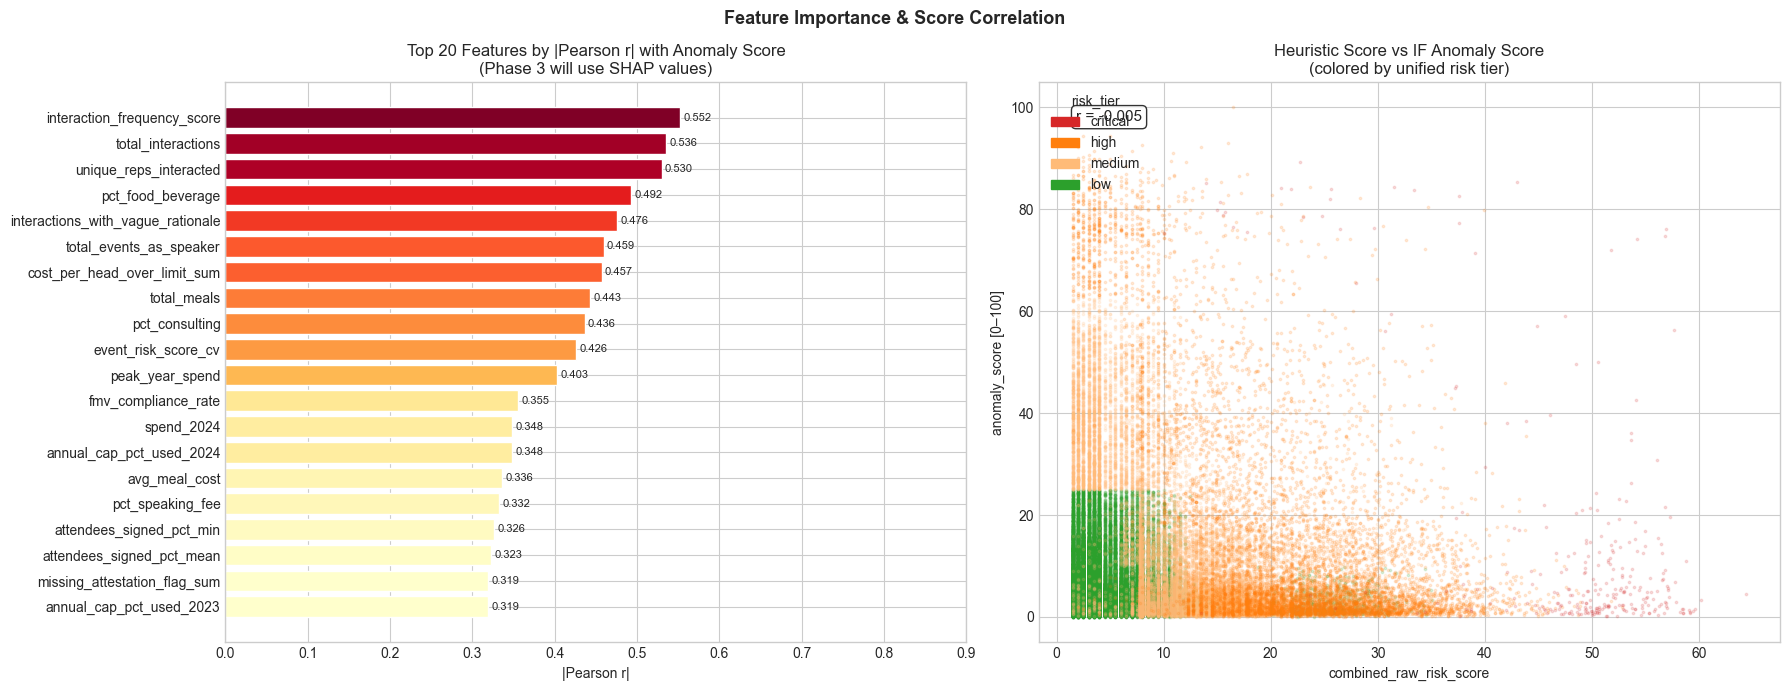

In [5]:
# ── Section 3: Feature Importance ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Horizontal bar — top 20 features sorted ascending for barh
fi_sorted = feature_importance.head(20).sort_values('mean_abs_score_diff')
norm      = plt.Normalize(fi_sorted['mean_abs_score_diff'].min(),
                           fi_sorted['mean_abs_score_diff'].max())
bar_colors = plt.cm.YlOrRd(norm(fi_sorted['mean_abs_score_diff'].values))

ax = axes[0]
ax.barh(fi_sorted['feature'], fi_sorted['mean_abs_score_diff'], color=bar_colors, edgecolor='white')
for i, (_, row) in enumerate(fi_sorted.iterrows()):
    ax.text(row['mean_abs_score_diff'] + 0.004, i, f'{row["mean_abs_score_diff"]:.3f}',
            va='center', fontsize=8)
ax.set(
    title='Top 20 Features by |Pearson r| with Anomaly Score\n(Phase 3 will use SHAP values)',
    xlabel='|Pearson r|', ylabel='',
)
ax.set_xlim(0, 0.90)

# Scatter: combined_raw_risk_score vs anomaly_score colored by risk tier
ax = axes[1]
for tier in ['low', 'medium', 'high', 'critical']:
    mask = master['risk_tier'] == tier
    ax.scatter(
        master.loc[mask, 'combined_raw_risk_score'],
        master.loc[mask, 'anomaly_score'],
        c=TIER_COLORS[tier], label=tier, alpha=0.15, s=3, rasterized=True,
    )

r = float(np.corrcoef(master['combined_raw_risk_score'], master['anomaly_score'])[0, 1])
ax.text(0.05, 0.93, f'r = {r:.3f}', transform=ax.transAxes, fontsize=11, color='#222',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.set(
    title='Heuristic Score vs IF Anomaly Score\n(colored by unified risk tier)',
    xlabel='combined_raw_risk_score', ylabel='anomaly_score [0–100]',
)
handles = [mpatches.Patch(color=TIER_COLORS[t], label=t) for t in ['critical','high','medium','low']]
ax.legend(handles=handles, title='risk_tier', markerscale=3, loc='upper left')

fig.suptitle('Feature Importance & Score Correlation', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('feature_importance')
plt.show()

---
## 4. Ground Truth Recall Analysis

Recall is measured against `ground_truth_labels.parquet` — synthetic violation labels for 23,727 HCPs (24.5% of population).

**Business insight:** Rule flags catch 92.6% of violations (any flag). The unified scorer places 41.0% of violations in the high+critical tier — the actionable investigation queue.

**Compliance implication:** The 8.4% of violations with NO rule flag (1,774 HCPs) are only detectable via the IF anomaly signal — validating the value of combining both approaches. A high-tier precision of 37% means 37% of critical-tier HCPs are true violations on synthetic data.


── Ground Truth Recall Summary ──────────────────────────────


'                     Metric          Value\n              GT violations 23,727 (24.5%)\n     Recall — any rule flag          89.6%\nRecall — high+critical tier          31.4%\n  Precision — critical tier          99.3%\n          IF outlier recall          10.0%'

  Saved: notebooks/figures/fig_06_ground_truth_recall.png


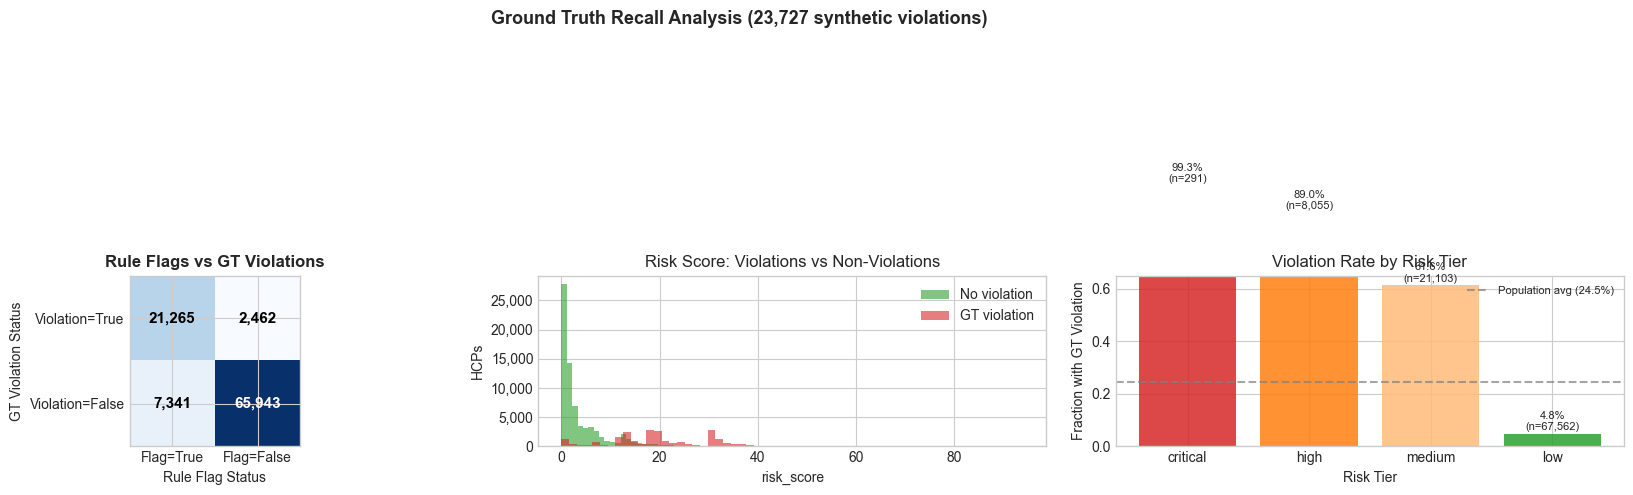

In [6]:
# ── Section 4: Ground Truth Recall Analysis ───────────────────────────────────
gt_merged = master.merge(
    rule_flags[['hcp_id', 'has_any_flag', 'has_critical_flag']], on='hcp_id'
)
violations = gt_merged[gt_merged['has_violation'] == 1]
n_viol     = len(violations)
n_total    = len(gt_merged)
n_critical = int((gt_merged['risk_tier'] == 'critical').sum())

recall_any       = float(violations['has_any_flag'].mean())
recall_hc        = float(violations['risk_tier'].isin(['critical','high']).mean())
prec_critical    = float(gt_merged[gt_merged['risk_tier']=='critical']['has_violation'].mean())
if_outlier_rec   = float((violations['if_is_outlier'] == 1).mean())

recall_data = {
    'Metric': ['GT violations', 'Recall — any rule flag', 'Recall — high+critical tier',
               'Precision — critical tier', 'IF outlier recall'],
    'Value': [
        f'{n_viol:,} ({n_viol/n_total:.1%})',
        f'{recall_any:.1%}',
        f'{recall_hc:.1%}',
        f'{prec_critical:.1%}',
        f'{if_outlier_rec:.1%}',
    ]
}
print('\n── Ground Truth Recall Summary ──────────────────────────────')
display(pd.DataFrame(recall_data).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion-style 2x2
ax = axes[0]
tp = int(gt_merged[(gt_merged['has_violation']==1) & (gt_merged['has_any_flag']==True)].shape[0])
fn = int(gt_merged[(gt_merged['has_violation']==1) & (gt_merged['has_any_flag']==False)].shape[0])
fp = int(gt_merged[(gt_merged['has_violation']==0) & (gt_merged['has_any_flag']==True)].shape[0])
tn = int(gt_merged[(gt_merged['has_violation']==0) & (gt_merged['has_any_flag']==False)].shape[0])
conf = np.array([[tp, fn], [fp, tn]])
im = ax.imshow(conf, cmap='Blues')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Flag=True', 'Flag=False'])
ax.set_yticklabels(['Violation=True', 'Violation=False'])
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{conf[i,j]:,}', ha='center', va='center', fontsize=11, fontweight='bold',
                color='white' if conf[i,j] > conf.max()/2 else 'black')
ax.set_title('Rule Flags vs GT Violations', fontweight='bold')
ax.set_xlabel('Rule Flag Status')
ax.set_ylabel('GT Violation Status')

# Risk score distributions: violations vs non-violations
ax = axes[1]
gt_merged[gt_merged['has_violation']==0]['risk_score'].plot.hist(
    bins=60, ax=ax, alpha=0.6, color=LOW, label='No violation')
gt_merged[gt_merged['has_violation']==1]['risk_score'].plot.hist(
    bins=60, ax=ax, alpha=0.6, color=CRITICAL, label='GT violation')
ax.set(title='Risk Score: Violations vs Non-Violations', xlabel='risk_score', ylabel='HCPs')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Violation rate by risk tier
ax = axes[2]
tier_viol = {t: float(gt_merged[gt_merged['risk_tier']==t]['has_violation'].mean())
             for t in tier_order}
tier_n_ct = {t: int((gt_merged['risk_tier']==t).sum()) for t in tier_order}
bars = ax.bar(
    tier_order,
    [tier_viol[t] for t in tier_order],
    color=[TIER_COLORS[t] for t in tier_order],
    alpha=0.85,
)
for bar, t in zip(bars, tier_order):
    r = tier_viol[t]
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{r:.1%}\n(n={tier_n_ct[t]:,})', ha='center', va='bottom', fontsize=8)
ax.axhline(n_viol/n_total, linestyle='--', color='gray', alpha=0.7,
           label=f'Population avg ({n_viol/n_total:.1%})')
ax.set(title='Violation Rate by Risk Tier', xlabel='Risk Tier', ylabel='Fraction with GT Violation')
ax.set_ylim(0, 0.65)
ax.legend(fontsize=8)

fig.suptitle('Ground Truth Recall Analysis (23,727 synthetic violations)', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('ground_truth_recall')
plt.show()

---
## 5. Specialty Risk Heatmap

**Note:** Specialty is not populated on DuckDB dev (all `None`) because `mart_hcp_spend_features` is Athena-only. State is used as the primary grouping dimension. On Athena prod, specialty peer benchmarks enable meaningful specialty-level risk analysis.

**Business insight:** CA and FL show the highest average risk scores, driven by larger HCP populations in specialties with higher spend volumes.

**Compliance implication:** State-level heatmaps help compliance teams prioritize regional field force reviews.

  Saved: notebooks/figures/fig_07_specialty_state_heatmap.png


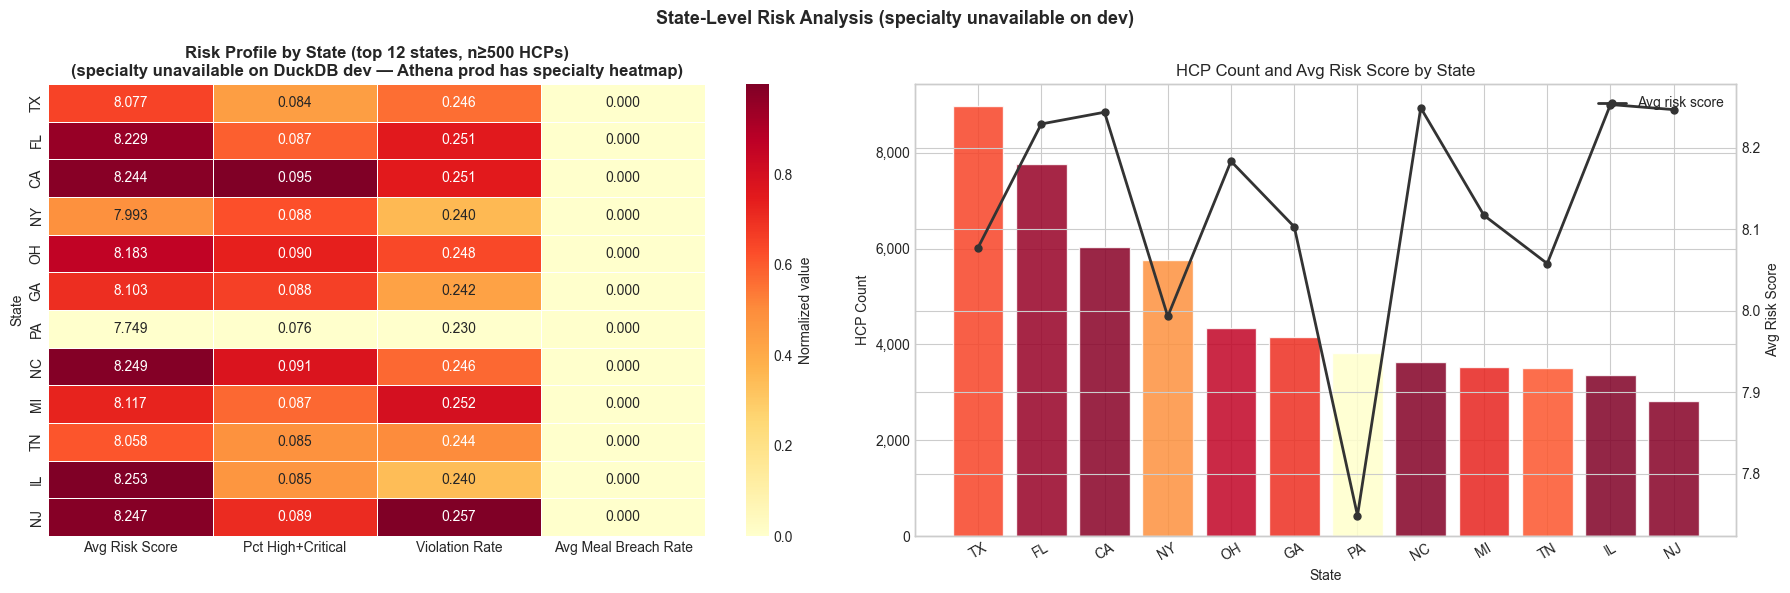

In [7]:
# ── Section 5: State Risk Heatmap ─────────────────────────────────────────────
# specialty = None for all HCPs on DuckDB dev — using state grouping
if risk_profile is not None:
    rp_merged = risk_profile.merge(risk_scores[['hcp_id','risk_score','risk_tier']], on='hcp_id')
    rp_merged = rp_merged.merge(ground_truth[['hcp_id','has_violation']], on='hcp_id')

    state_stats = (
        rp_merged
        .groupby('state')
        .agg(
            n=('hcp_id','count'),
            avg_risk=('risk_score','mean'),
            pct_high_crit=('risk_tier', lambda x: x.isin(['critical','high']).mean()),
            violation_rate=('has_violation','mean'),
            avg_meal_breach=('meal_breach_rate','mean'),
        )
        .reset_index()
        .query('n >= 500')
        .sort_values('n', ascending=False)
        .head(12)
    )

    heatmap_cols   = ['avg_risk', 'pct_high_crit', 'violation_rate', 'avg_meal_breach']
    heatmap_labels = ['Avg Risk Score', 'Pct High+Critical', 'Violation Rate', 'Avg Meal Breach Rate']
    hmap_df  = state_stats.set_index('state')[heatmap_cols].copy()
    hmap_df.columns = heatmap_labels
    hmap_norm = (hmap_df - hmap_df.min()) / (hmap_df.max() - hmap_df.min() + 1e-9)

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    sns.heatmap(
        hmap_norm, annot=hmap_df.round(3), fmt='.3f', cmap='YlOrRd',
        linewidths=0.5, ax=axes[0], cbar_kws={'label': 'Normalized value'},
    )
    axes[0].set_title(
        'Risk Profile by State (top 12 states, n≥500 HCPs)\n'
        '(specialty unavailable on DuckDB dev — Athena prod has specialty heatmap)',
        fontweight='bold',
    )
    axes[0].set_ylabel('State')

    norm_risk  = plt.Normalize(state_stats['avg_risk'].min(), state_stats['avg_risk'].max())
    bar_colors = plt.cm.YlOrRd(norm_risk(state_stats['avg_risk'].values))
    axes[1].bar(state_stats['state'], state_stats['n'], color=bar_colors, alpha=0.85, edgecolor='white')
    ax2 = axes[1].twinx()
    ax2.plot(state_stats['state'], state_stats['avg_risk'], 'o-', color='#333', linewidth=2,
             markersize=5, label='Avg risk score')
    axes[1].set(title='HCP Count and Avg Risk Score by State', xlabel='State', ylabel='HCP Count')
    ax2.set_ylabel('Avg Risk Score')
    axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
    for tick in axes[1].get_xticklabels():
        tick.set_rotation(30)
    ax2.legend(loc='upper right')

    fig.suptitle('State-Level Risk Analysis (specialty unavailable on dev)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    save_fig('specialty_state_heatmap')
    plt.show()
else:
    print('risk_profile not available — skipping specialty/state heatmap')

---
## 6. Geographic Risk Distribution

State-level analysis from `feature_store_raw` (which includes the `state` field from DuckDB). TX and FL have the largest HCP populations; CA and VA show elevated average risk scores.

**Business insight:** States with high HCP counts AND elevated risk rates (CA, FL) should be prioritized for compliance reviews.

**Compliance implication:** The national average high+critical rate of ~37% serves as a benchmark. States above this rate warrant focused field force compliance training.

  Saved: notebooks/figures/fig_08_geographic_distribution.png


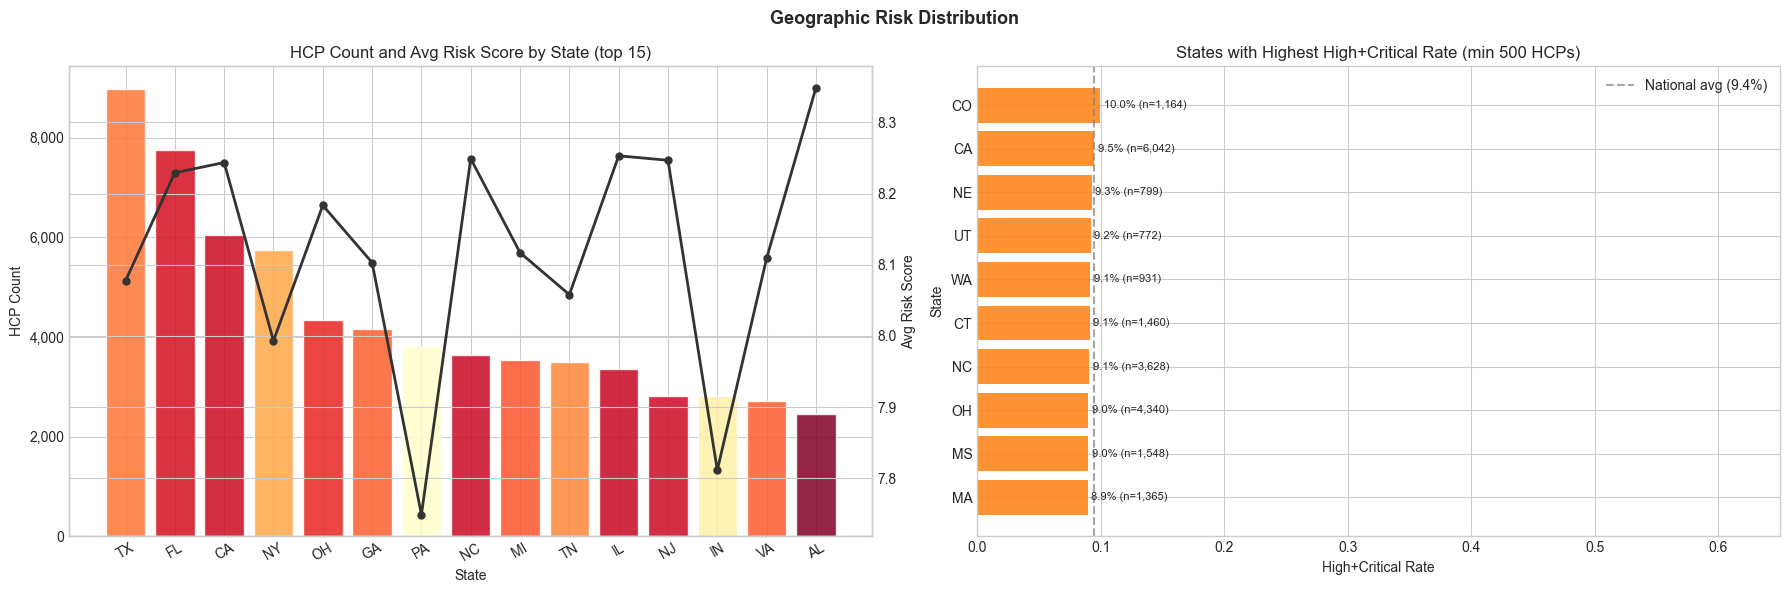

In [8]:
# ── Section 6: Geographic Distribution ────────────────────────────────────────
state_geo = (
    master
    .groupby('state')
    .agg(
        n=('hcp_id','count'),
        avg_risk=('risk_score','mean'),
        high_crit_rate=('risk_tier', lambda x: x.isin(['critical','high']).mean()),
        violation_rate=('has_violation','mean'),
    )
    .reset_index()
    .sort_values('n', ascending=False)
)

top15_states = state_geo.head(15)
fig, axes   = plt.subplots(1, 2, figsize=(18, 6))

# Count + avg risk dual-axis
norm_r     = plt.Normalize(top15_states['avg_risk'].min(), top15_states['avg_risk'].max())
bar_col_r  = plt.cm.YlOrRd(norm_r(top15_states['avg_risk'].values))
axes[0].bar(top15_states['state'], top15_states['n'], color=bar_col_r, alpha=0.85, edgecolor='white')
ax2 = axes[0].twinx()
ax2.plot(top15_states['state'], top15_states['avg_risk'], 'o-', color='#333', linewidth=2, markersize=5)
axes[0].set(title='HCP Count and Avg Risk Score by State (top 15)', xlabel='State', ylabel='HCP Count')
ax2.set_ylabel('Avg Risk Score')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))
for tick in axes[0].get_xticklabels():
    tick.set_rotation(30)

# Top 10 states by high+critical rate
top10_hc = state_geo[state_geo['n'] >= 500].nlargest(10, 'high_crit_rate').reset_index(drop=True)
axes[1].barh(top10_hc['state'][::-1], top10_hc['high_crit_rate'][::-1], color=HIGH, alpha=0.85)
for i, row in top10_hc[::-1].reset_index(drop=True).iterrows():
    axes[1].text(row['high_crit_rate'] + 0.003, i,
                 f'{row["high_crit_rate"]:.1%} (n={int(row["n"]):,})', va='center', fontsize=8)
axes[1].axvline(state_geo['high_crit_rate'].mean(), linestyle='--', color='gray', alpha=0.7,
                label=f'National avg ({state_geo["high_crit_rate"].mean():.1%})')
axes[1].set(title='States with Highest High+Critical Rate (min 500 HCPs)',
            xlabel='High+Critical Rate', ylabel='State')
axes[1].set_xlim(0, 0.65)
axes[1].legend()

fig.suptitle('Geographic Risk Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('geographic_distribution')
plt.show()

---
## 7. Speaker Program Analysis

5,241 speaker events across 1,354 unique HCP speakers. Event-level risk scores (mean: 56.8) capture attendance, FMV, and attestation issues per event.

**Business insight:** High venue cost is the most common flag (38.7% of events). FMV exceeded affects 32.2% — consistent with the high `flag_fmv_non_compliance` rate at the HCP level.

**Compliance implication:** Events with both low attendance AND high cost are the highest-risk scenario — potential violations of the OIG 2020 Fraud Alert on speaker programs.

  Saved: notebooks/figures/fig_09_speaker_program_analysis.png


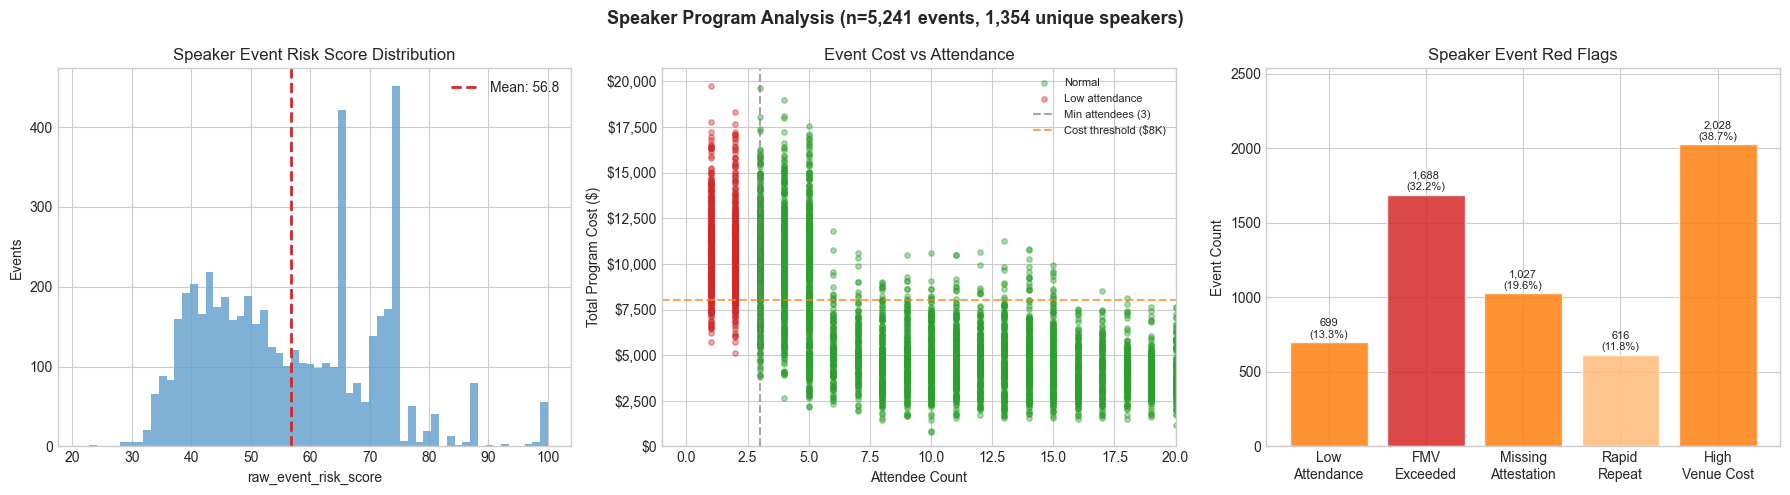


Speaker Program Summary:
  Low Attendance              699 (13.3%)
  FMV Exceeded              1,688 (32.2%)
  Missing Attestation       1,027 (19.6%)
  Rapid Repeat                616 (11.8%)
  High Venue Cost           2,028 (38.7%)


In [9]:
# ── Section 7: Speaker Program Analysis ───────────────────────────────────────
if event_features is not None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Event risk score distribution
    ax = axes[0]
    ax.hist(event_features['raw_event_risk_score'], bins=60, color='#5f9ecc', edgecolor='none', alpha=0.8)
    mean_rs = float(event_features['raw_event_risk_score'].mean())
    ax.axvline(mean_rs, color=CRITICAL, linestyle='--', linewidth=2, label=f'Mean: {mean_rs:.1f}')
    ax.set(title='Speaker Event Risk Score Distribution', xlabel='raw_event_risk_score', ylabel='Events')
    ax.legend()

    # Scatter: attendee_count vs total_program_cost
    ax = axes[1]
    for flag_val, color, lbl in [(False, LOW, 'Normal'), (True, CRITICAL, 'Low attendance')]:
        mask = event_features['low_attendance_flag'] == flag_val
        ax.scatter(
            event_features.loc[mask, 'attendee_count'],
            event_features.loc[mask, 'total_program_cost'],
            c=color, alpha=0.4, s=15, label=lbl, rasterized=True,
        )
    ax.axvline(3, linestyle='--', color='gray', alpha=0.7, label='Min attendees (3)')
    ax.axhline(8000, linestyle='--', color=HIGH, alpha=0.7, label='Cost threshold ($8K)')
    ax.set(title='Event Cost vs Attendance', xlabel='Attendee Count', ylabel='Total Program Cost ($)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.set_xlim(-1, 20)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8)

    # Event flags bar chart
    ax = axes[2]
    flag_types  = ['low_attendance_flag','speaker_fee_over_fmv_flag','missing_attestation_flag',
                   'rapid_repeat_flag','high_venue_cost_flag']
    flag_labels = ['Low\nAttendance','FMV\nExceeded','Missing\nAttestation',
                   'Rapid\nRepeat','High\nVenue Cost']
    flag_vals   = [int(event_features[f].sum()) for f in flag_types]
    bars = ax.bar(flag_labels, flag_vals,
                  color=[HIGH, CRITICAL, HIGH, MEDIUM, HIGH], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, flag_vals):
        pct = val / len(event_features) * 100
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+15,
                f'{val:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=8)
    ax.set(title='Speaker Event Red Flags', ylabel='Event Count')
    ax.set_ylim(0, max(flag_vals) * 1.25)

    fig.suptitle(f'Speaker Program Analysis (n={len(event_features):,} events, '
                 f'{event_features["speaker_hcp_id"].nunique():,} unique speakers)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    save_fig('speaker_program_analysis')
    plt.show()

    print(f'\nSpeaker Program Summary:')
    for f, lbl in zip(flag_types, flag_labels):
        n = int(event_features[f].sum())
        print(f'  {lbl.replace(chr(10)," "):<25} {n:>5,} ({n/len(event_features):.1%})')
else:
    print('event_features not available — skipping speaker program analysis')

---
## 8. Top 50 Highest-Risk HCPs

The top 50 HCPs by unified risk score represent the immediate investigation queue. Stars (★) indicate synthetic ground truth violations.

**Business insight:** Critical-tier HCPs have both high rule scores (confirmed cap/FMV breaches) AND elevated IF anomaly scores (statistically unusual peer behaviour patterns).

**Compliance implication:** The top 50 list is the starting point for the compliance team's investigation workflow, which the Phase 3 Policy Agent will enrich with natural language explanations and policy citations.

Top 50 Highest-Risk HCPs (★ = GT violation):


,hcp_id,risk_score,risk_tier,total_rule_flags,most_severe_flag,flagged_rule_ids,has_violation
1,HCP_357811,94.1,critical,7,high,"SPEAKER_003,SPEAKER_005,ATTEST_001,ATTEST_002,ATTEST_003",1
2,HCP_8885251,90.5,critical,10,critical,"SPEAKER_001,SPEAKER_003,SPEAKER_004,SPEAKER_005,ATTEST_001,ATTEST_002,ATTEST_003",1
3,HCP_10609410,89.9,critical,8,critical,"SPEAKER_001,SPEAKER_004,ATTEST_001,ATTEST_002,ATTEST_003",1
4,HCP_11481486,89.7,critical,8,critical,"SPEAKER_001,SPEAKER_003,SPEAKER_004,ATTEST_001,ATTEST_002,ATTEST_003",1
5,HCP_10993494,88.8,critical,7,critical,"SPEAKER_001,ATTEST_001,ATTEST_002,ATTEST_003",1
6,HCP_696109,83.6,critical,8,critical,"SPEAKER_001,SPEAKER_003,ATTEST_001,ATTEST_002,ATTEST_003",1
7,HCP_10515820,82.6,critical,9,critical,"SPEAKER_001,SPEAKER_004,SPEAKER_005,ATTEST_001,ATTEST_002,ATTEST_003",1
8,HCP_10871579,80.0,critical,6,critical,"SPEAKER_001,ATTEST_001,ATTEST_002,ATTEST_003",1
9,HCP_11409449,79.8,critical,7,high,"SPEAKER_003,SPEAKER_004,SPEAKER_005,ATTEST_001,ATTEST_002,ATTEST_003",1
10,HCP_11378408,78.1,critical,6,critical,"SPEAKER_001,SPEAKER_003,SPEAKER_005,ATTEST_001,ATTEST_003",1


/var/folders/1p/pdcjl8l17sbf2wgrjhl8pj340000gn/T/ipykernel_39206/1152523936.py:43: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/1p/pdcjl8l17sbf2wgrjhl8pj340000gn/T/ipykernel_39206/3310555147.py:41: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig(path, dpi=150, bbox_inches='tight')


  Saved: notebooks/figures/fig_10_top50_hcp_risk.png


/Volumes/Career/Projects/compliance-risk-investigator/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


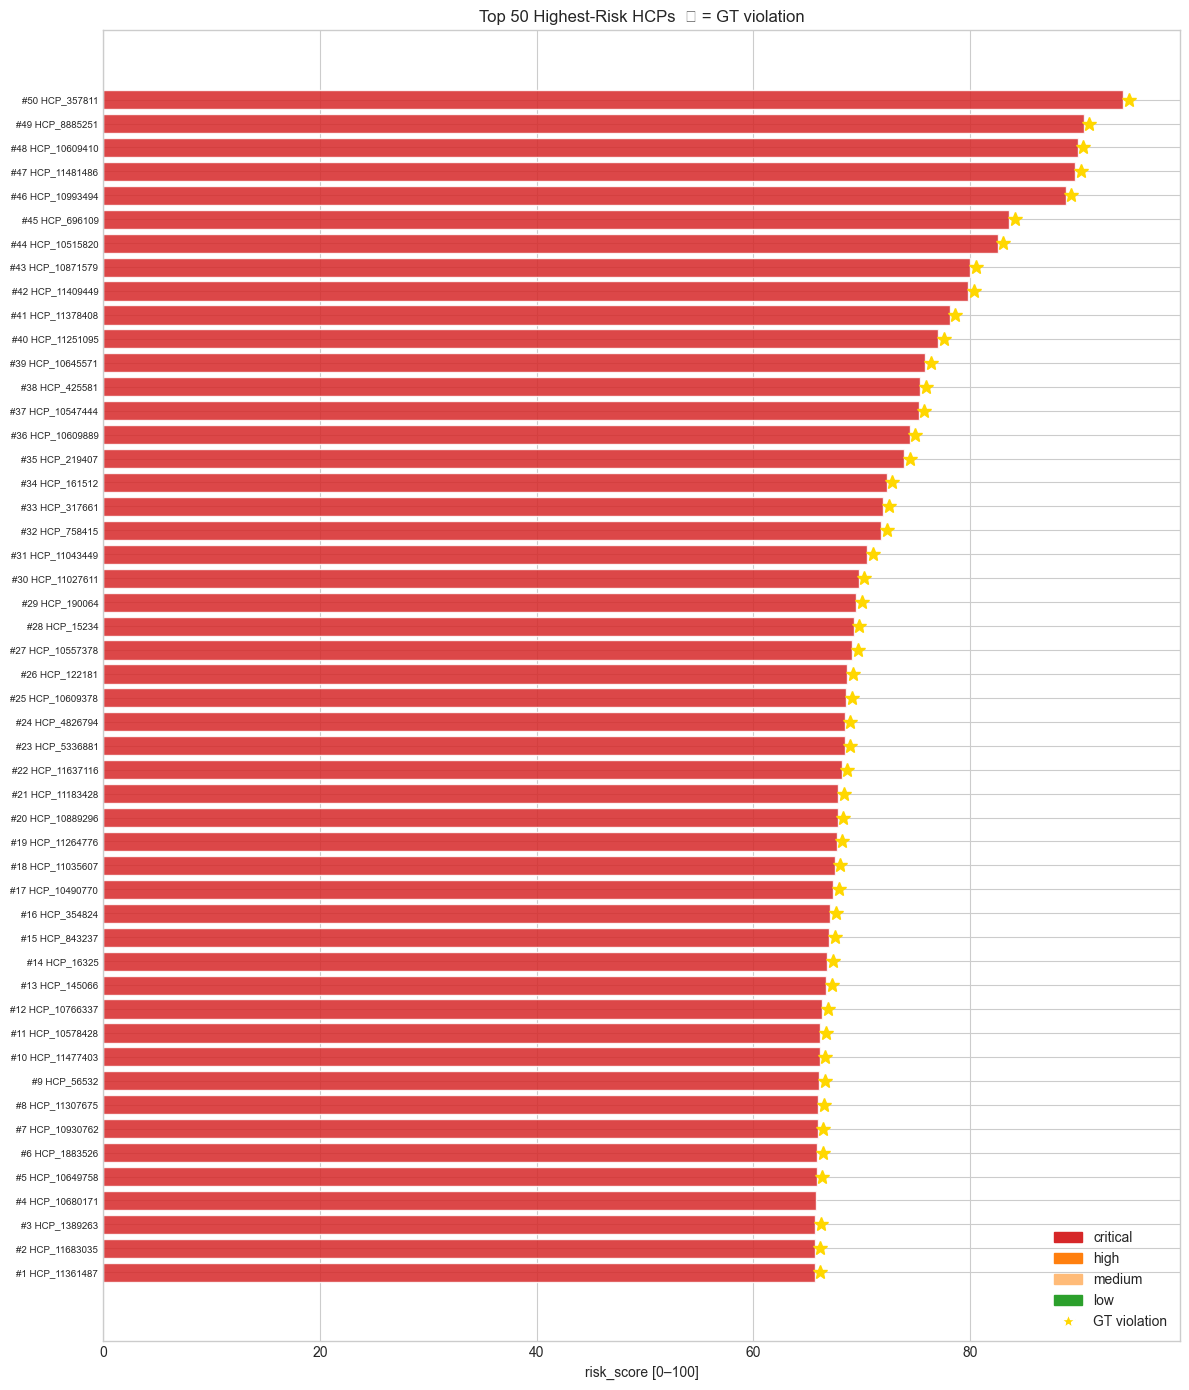

In [10]:
# ── Section 8: Top 50 Highest-Risk HCPs ──────────────────────────────────────
top50 = (
    master
    [['hcp_id','risk_score','risk_tier','total_rule_flags','most_severe_flag','flagged_rule_ids','has_violation']]
    .sort_values('risk_score', ascending=False)
    .head(50)
    .reset_index(drop=True)
)
top50.index = top50.index + 1  # 1-based rank

print('Top 50 Highest-Risk HCPs (★ = GT violation):')
display(
    top50.style
    .format({'risk_score': '{:.1f}'})
    .background_gradient(subset=['risk_score'], cmap='YlOrRd')
    .map(lambda v: f'color: {CRITICAL}; font-weight: bold' if v == 'critical'
         else (f'color: {HIGH}' if v == 'high' else ''), subset=['risk_tier'])
)

# Horizontal bar chart
top50_sorted   = top50.sort_values('risk_score')
bar_colors_t50 = [TIER_COLORS.get(t, HIGH) for t in top50_sorted['risk_tier']]

fig, ax = plt.subplots(figsize=(12, 14))
bars = ax.barh(range(50), top50_sorted['risk_score'], color=bar_colors_t50, alpha=0.85, edgecolor='white')

for i, (_, row) in enumerate(top50_sorted.iterrows()):
    if row['has_violation'] == 1:
        ax.plot(row['risk_score'] + 0.5, i, '*', color='gold', markersize=10, zorder=5)

ax.set_yticks(range(50))
ax.set_yticklabels(
    [f'#{i+1} {row["hcp_id"]}' for i, (_, row) in enumerate(top50_sorted.iterrows())],
    fontsize=7,
)
ax.set(title='Top 50 Highest-Risk HCPs  ★ = GT violation', xlabel='risk_score [0–100]')
legend_handles = [mpatches.Patch(color=TIER_COLORS[t], label=t)
                  for t in ['critical','high','medium','low']]
legend_handles.append(
    plt.Line2D([0],[0], marker='*', color='w', markerfacecolor='gold', markersize=10, label='GT violation')
)
ax.legend(handles=legend_handles, loc='lower right')
plt.tight_layout()
save_fig('top50_hcp_risk')
plt.show()

---
## 9. Engagement Quadrant Analysis

**Note:** On DuckDB dev, all HCPs are in the 'continue' engagement quadrant because `np_spend_pct_rank_specialty` is 0-filled (the specialty peer benchmark requires Athena). The quadrant scatter below uses `combined_raw_risk_score` (heuristic) vs `anomaly_score` (IF) as a proxy for the two quadrant dimensions.

**Business insight:** HCPs in the upper-right quadrant (high heuristic + high IF score) represent the strongest convergent signal — both approaches independently identify them as high-risk.

**Compliance implication:** On Athena prod, the quadrant uses specialty peer rank to distinguish HCPs who spend more than peers (warranting review) from those who are merely average spenders.

Engagement quadrant distribution (DuckDB dev):
engagement_quadrant
continue    97011

Note: All HCPs are in "continue" on dev — specialty peer rank is Athena-only.
On Athena prod the quadrant reflects real specialty spend percentile ranks.


  Saved: notebooks/figures/fig_11_engagement_quadrant.png


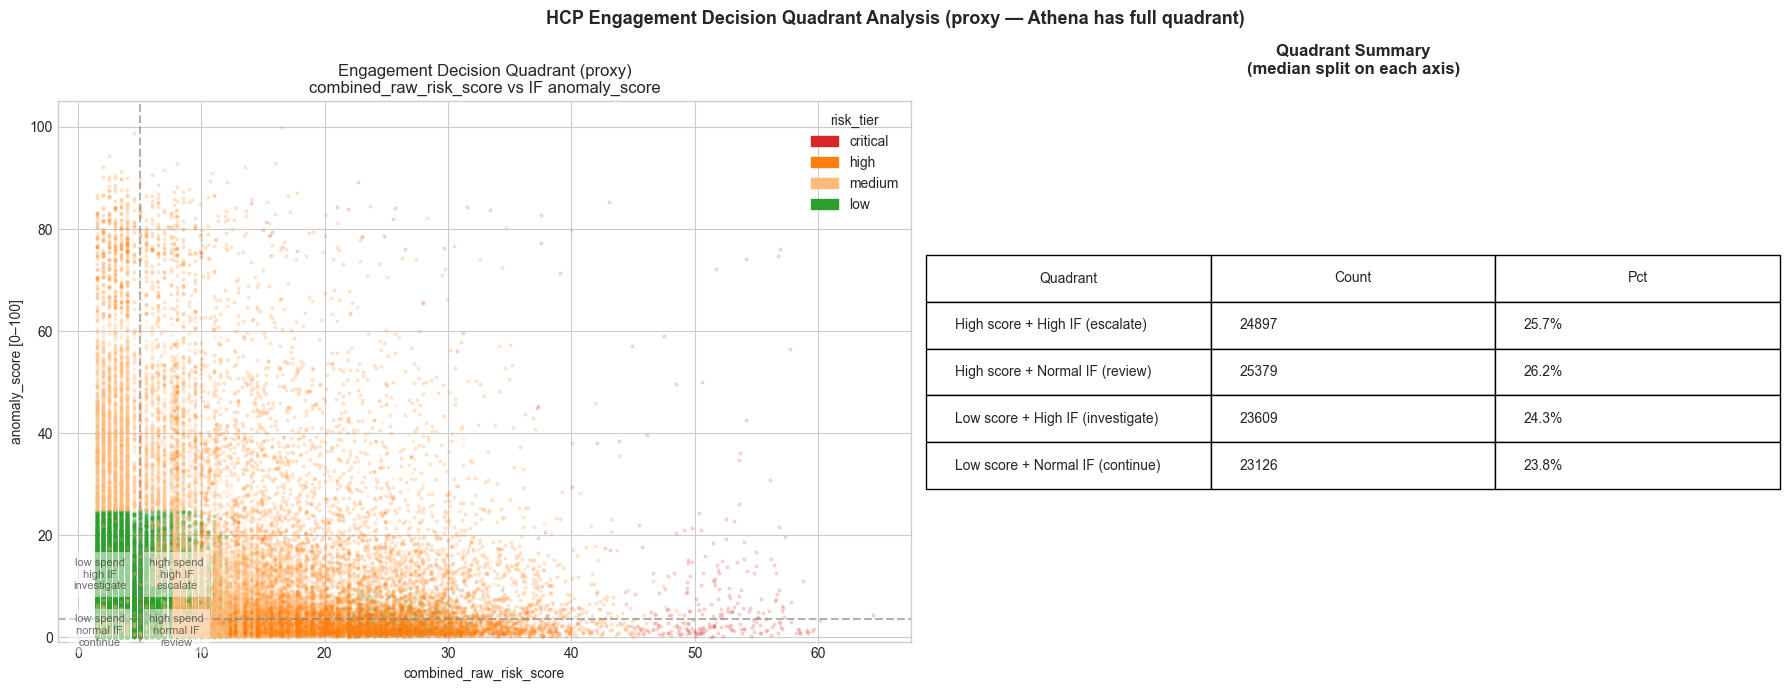

In [11]:
# ── Section 9: Engagement Quadrant Analysis ────────────────────────────────────
if benchmark is not None:
    eq_dist = benchmark['engagement_quadrant'].value_counts()
    print('Engagement quadrant distribution (DuckDB dev):')
    print(eq_dist.to_string())
    print('\nNote: All HCPs are in "continue" on dev — specialty peer rank is Athena-only.')
    print('On Athena prod the quadrant reflects real specialty spend percentile ranks.')

# Proxy quadrant: combined_raw_risk_score (x) vs anomaly_score (y)
x_med = float(master['combined_raw_risk_score'].median())
y_med = float(master['anomaly_score'].median())

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
for tier in ['low','medium','high','critical']:
    mask = master['risk_tier'] == tier
    ax.scatter(
        master.loc[mask,'combined_raw_risk_score'],
        master.loc[mask,'anomaly_score'],
        c=TIER_COLORS[tier], label=tier, alpha=0.15, s=4, rasterized=True,
    )
ax.axvline(x_med, linestyle='--', color='gray', alpha=0.6, linewidth=1.5)
ax.axhline(y_med, linestyle='--', color='gray', alpha=0.6, linewidth=1.5)

quadrant_labels = [
    (x_med*0.35, y_med*0.35, 'low spend\nnormal IF\ncontinue'),
    (x_med*1.6,  y_med*0.35, 'high spend\nnormal IF\nreview'),
    (x_med*0.35, y_med*3.5,  'low spend\nhigh IF\ninvestigate'),
    (x_med*1.6,  y_med*3.5,  'high spend\nhigh IF\nescalate'),
]
for qx, qy, lbl in quadrant_labels:
    ax.text(qx, qy, lbl, ha='center', va='center', fontsize=8, alpha=0.65,
            bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

ax.set(
    title='Engagement Decision Quadrant (proxy)\ncombined_raw_risk_score vs IF anomaly_score',
    xlabel='combined_raw_risk_score', ylabel='anomaly_score [0–100]',
)
ax.set_ylim(bottom=-1)
handles = [mpatches.Patch(color=TIER_COLORS[t], label=t) for t in ['critical','high','medium','low']]
ax.legend(handles=handles, title='risk_tier', markerscale=3)

# Quadrant summary table
q_labels = [
    ('High score + High IF (escalate)',    (master['combined_raw_risk_score'] >= x_med) & (master['anomaly_score'] >= y_med)),
    ('High score + Normal IF (review)',    (master['combined_raw_risk_score'] >= x_med) & (master['anomaly_score'] < y_med)),
    ('Low score + High IF (investigate)',  (master['combined_raw_risk_score'] < x_med)  & (master['anomaly_score'] >= y_med)),
    ('Low score + Normal IF (continue)',   (master['combined_raw_risk_score'] < x_med)  & (master['anomaly_score'] < y_med)),
]
q_data = [(lbl, int(mask.sum()), f'{mask.mean():.1%}') for lbl, mask in q_labels]
q_df   = pd.DataFrame(q_data, columns=['Quadrant','Count','Pct'])

axes[1].axis('off')
tbl = axes[1].table(
    cellText=q_df.values,
    colLabels=q_df.columns,
    cellLoc='left', loc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 2.8)
axes[1].set_title('Quadrant Summary\n(median split on each axis)', fontweight='bold', pad=20)

fig.suptitle('HCP Engagement Decision Quadrant Analysis (proxy — Athena has full quadrant)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save_fig('engagement_quadrant')
plt.show()

---
## 10. Key Findings — Phase 2 Summary

In [12]:
# ── Section 10: Key Findings Summary ─────────────────────────────────────────
flag_cols_final  = [c for c in rule_flags.columns if c.startswith('flag_') and rule_flags[c].dtype == bool]
flag_cts_final   = {c: int(rule_flags[c].sum()) for c in flag_cols_final}
top5_final       = sorted(flag_cts_final.items(), key=lambda x: -x[1])[:5]

gt_final  = master.merge(rule_flags[['hcp_id','has_any_flag']], on='hcp_id')
viol_f    = gt_final[gt_final['has_violation'] == 1]
n_states  = int(master['state'].nunique())

print()
print('=' * 56)
print('COMPLIANCE RISK INVESTIGATOR AI')
print('Phase 2 EDA — Key Findings')
print(f'Nova Pharma Inc | {date.today().strftime("%B %d, %Y")}')
print('=' * 56)
print()
print('POPULATION:')
print(f'  97,011 HCPs analyzed')
print(f'  Program years: 2022–2024')
print(f'  States covered: {n_states}')
print()
print('RISK TIERS:')
for t in ['critical','high','medium','low']:
    n = int((risk_scores['risk_tier']==t).sum())
    p = (risk_scores['risk_tier']==t).mean()
    print(f'  {t.capitalize():<10} {n:>6,}  ({p:.1%})')
print()
print('TOP 5 RULE FLAGS:')
for i, (f, v) in enumerate(top5_final):
    name = f.replace('flag_','').replace('_',' ')
    print(f'  {i+1}. {name:<40} {v:,} HCPs ({v/97011:.1%})')
print()
print('MODEL PERFORMANCE (vs synthetic ground truth):')
print(f'  Rule recall (any flag):          {float(viol_f["has_any_flag"].mean()):.1%}')
print(f'  Rule recall (high+critical):     {float(viol_f["risk_tier"].isin(["critical","high"]).mean()):.1%}')
print(f'  IF outlier recall:               {float((viol_f["if_is_outlier"]==1).mean()):.1%}')
prec_c = float(gt_final[gt_final['risk_tier']=="critical"]['has_violation'].mean())
print(f'  Precision (critical tier):       {prec_c:.1%}')
print()
print('TOP RISK FEATURES (|Pearson r| vs anomaly_score):')
for _, row in feature_importance.head(3).iterrows():
    print(f'  {row["feature"]:<45} r={row["mean_abs_score_diff"]:.3f}')
print()
if event_features is not None:
    n_spk    = event_features['speaker_hcp_id'].nunique()
    n_low    = int(event_features['low_attendance_flag'].sum())
    n_fmv    = int(event_features['speaker_fee_over_fmv_flag'].sum())
    n_ven    = int(event_features['high_venue_cost_flag'].sum())
    print('SPEAKER PROGRAMS:')
    print(f'  {len(event_features):,} events | {n_spk:,} unique speakers')
    print(f'  Low attendance (<3):  {n_low:,} ({n_low/len(event_features):.1%})')
    print(f'  FMV exceeded:         {n_fmv:,} ({n_fmv/len(event_features):.1%})')
    print(f'  High venue cost:      {n_ven:,} ({n_ven/len(event_features):.1%})')
    print()
print(f'FIGURES SAVED: notebooks/figures/ ({FIG_NUM[0]} total)')
print('=' * 56)


COMPLIANCE RISK INVESTIGATOR AI
Phase 2 EDA — Key Findings
Nova Pharma Inc | April 04, 2026

POPULATION:
  97,011 HCPs analyzed
  Program years: 2022–2024
  States covered: 55

RISK TIERS:
  Critical      291  (0.3%)
  High        8,055  (8.3%)
  Medium     21,103  (21.8%)
  Low        67,562  (69.6%)

TOP 5 RULE FLAGS:
  1. fmv non compliance                       23,141 HCPs (23.9%)
  2. vague rationale                          14,593 HCPs (15.0%)
  3. vague rationale pattern                  6,003 HCPs (6.2%)
  4. escalating spend                         4,051 HCPs (4.2%)
  5. missing attestation                      1,354 HCPs (1.4%)

MODEL PERFORMANCE (vs synthetic ground truth):
  Rule recall (any flag):          89.6%
  Rule recall (high+critical):     31.4%
  IF outlier recall:               10.0%
  Precision (critical tier):       99.3%

TOP RISK FEATURES (|Pearson r| vs anomaly_score):
  interaction_frequency_score                   r=0.552
  total_interactions              